# 🚗 Highway Traffic Classification
**Model**: EfficientNet-B0 + Optical Flow  
---
| Step | Description |
|------|-------------|
| 1 | Install & Setup |
| 2 | Mount Drive |
| 3 | Parse Labels — with class distribution chart |
| 4 | Extract Frames + Optical Flow |
| 5 | Dataset Visualisation — frames, flow, statistics |
| 6 | Dataset & DataLoaders |
| 7 | Model Architecture |
| 8 | Focal Loss — with weight chart |
| 9 | Training Loop |
| 10 | 4-Fold Cross Validation |
| 11 | Training Curves — accuracy + loss + gap per fold |
| 12 | Confusion Matrix |
| 13 | Per-Class Performance Report |
| 14 | Final Results Dashboard |
| 15 | Save Model |
| 16 | Inference on New Video |

## ⚙️ Step 1 — Install & Setup

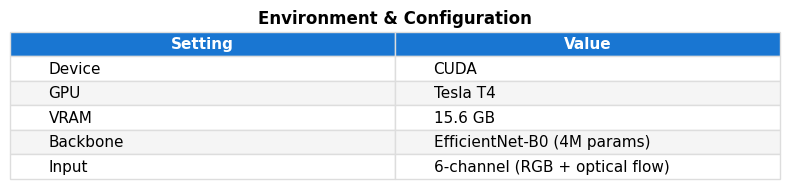

✅ Setup complete


In [2]:
!pip install -q timm scikit-learn seaborn

import os, cv2, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)
from sklearn.model_selection import train_test_split

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Constants ─────────────────────────────────────────────────────────────────
CLASS_NAMES   = ['light', 'medium', 'heavy']
CLASS_TO_IDX  = {'light': 0, 'medium': 1, 'heavy': 2}
CLASS_COLORS  = ['#4CAF50', '#FF9800', '#F44336']
FRAMES_DIR    = Path('/content/frames')
FRAMES_DIR.mkdir(exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE         = 224
FRAMES_PER_VIDEO = 8
BATCH_SIZE       = 16
EPOCHS           = 30
LR_HEAD          = 8e-4
LR_BACKBONE      = 5e-5
WEIGHT_DECAY     = 1e-4
PATIENCE         = 7
WARMUP_EPOCHS    = 3
MIXUP_ALPHA      = 0.15
DROPOUT          = 0.35
STOCH_DEPTH      = 0.15

# ── Device info visual ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')
gpu_name = torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'CPU'
mem_gb   = torch.cuda.get_device_properties(0).total_memory/1e9 if DEVICE.type == 'cuda' else 0
info = [
    ['Device',    str(DEVICE).upper()],
    ['GPU',       gpu_name],
    ['VRAM',      f'{mem_gb:.1f} GB'],
    ['Backbone',  'EfficientNet-B0 (4M params)'],
    ['Input',     '6-channel (RGB + optical flow)'],

]
tbl = ax.table(cellText=info, colLabels=['Setting', 'Value'],
               loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
tbl.scale(1, 1.6)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#dddddd')
    if r == 0: cell.set_facecolor('#1976D2'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0: cell.set_facecolor('#f5f5f5')
plt.title('Environment & Configuration', fontweight='bold', pad=8)
plt.tight_layout()
plt.savefig('/content/config.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Setup complete')

## 📂 Step 2 — Mount Drive & Verify Files

In [3]:
from google.colab import drive
drive.mount('/content/drive')

BASE = Path('/content/drive/MyDrive/ML lab Colab')
DATA_ROOT = None
for f in BASE.iterdir():
    if f.is_dir() and 'Highway' in f.name and 'Traffic' in f.name:
        DATA_ROOT = f; break
if DATA_ROOT is None:
    DATA_ROOT = BASE / 'Highway Traffic Videos Dataset'

VIDEO_DIR    = DATA_ROOT / 'video'
IMAGE_MASTER = DATA_ROOT / 'ImageMaster'
EVAL_TRAIN   = DATA_ROOT / 'EvalSet_train'
EVAL_TEST    = DATA_ROOT / 'EvalSet_test'

videos = list(VIDEO_DIR.glob('*.avi')) + list(VIDEO_DIR.glob('*.mp4'))

print(f'Folder : {DATA_ROOT.name}')
print()
for name, path in [('video/', VIDEO_DIR), ('ImageMaster', IMAGE_MASTER),
                   ('EvalSet_train', EVAL_TRAIN), ('EvalSet_test', EVAL_TEST)]:
    status = 'found' if path.exists() else 'MISSING — check your Drive folder'
    print(f'  {name:15s}: {status}')
print(f'  {"videos":15s}: {len(videos)} files')

Mounted at /content/drive
Folder : Highway Traffic Videos Dataset

  video/         : found
  ImageMaster    : found
  EvalSet_train  : found
  EvalSet_test   : found
  videos         : 254 files


## 🏷️ Step 3 — Parse Labels & Class Distribution

In [4]:
def parse_image_master(filepath):
    records = []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'): continue
            p = line.split('\t')
            if len(p) >= 3:
                records.append({'video_idx': int(p[0]),
                                'filename' : p[1].strip(),
                                'label'    : p[2].strip()})
    return pd.DataFrame(records)

def parse_eval_set(filepath):
    folds = []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line: folds.append([int(x) for x in line.split(',')])
    return folds

labels_df   = parse_image_master(IMAGE_MASTER)
train_folds = parse_eval_set(EVAL_TRAIN)
test_folds  = parse_eval_set(EVAL_TEST)

labels_df['video_path'] = labels_df['filename'].map({vf.stem: vf for vf in videos})
labels_df = labels_df.dropna(subset=['video_path']).reset_index(drop=True)
counts    = labels_df['label'].value_counts().reindex(CLASS_NAMES)

print(f'Total  : {len(labels_df)} videos  |  {len(train_folds)} folds')
print()
print('Class distribution:')
for cls, n in counts.items():
    pct = n / len(labels_df) * 100
    bar = '█' * int(pct / 2)
    print(f'  {cls:6s}: {n:3d}  ({pct:.1f}%)  {bar}')
print()
print('Fold sizes:')
for i, (tr, te) in enumerate(zip(train_folds, test_folds)):
    print(f'  Fold {i+1}: train={len(tr)}  test={len(te)}')


Total  : 254 videos  |  4 folds

Class distribution:
  light : 165  (65.0%)  ████████████████████████████████
  medium:  45  (17.7%)  ████████
  heavy :  44  (17.3%)  ████████

Fold sizes:
  Fold 1: train=191  test=63
  Fold 2: train=190  test=64
  Fold 3: train=190  test=64
  Fold 4: train=191  test=63


## 🌊 Step 4 — Extract Frames + Optical Flow

In [5]:
def extract_frames(video_path, n=FRAMES_PER_VIDEO):
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(1, max(total - 1, 1), n, dtype=int)
    frames = []
    for i in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ret, f = cap.read()
        if ret and f is not None: frames.append(f)
    cap.release()
    return frames

def compute_flow(frames):
    if len(frames) < 2:
        h, w = frames[0].shape[:2] if frames else (240, 320)
        return np.zeros((h, w, 3), dtype=np.uint8)
    mags, xs, ys = [], [], []
    for i in range(len(frames) - 1):
        g1 = cv2.cvtColor(frames[i],   cv2.COLOR_BGR2GRAY)
        g2 = cv2.cvtColor(frames[i+1], cv2.COLOR_BGR2GRAY)
        fl = cv2.calcOpticalFlowFarneback(g1, g2, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        m, _ = cv2.cartToPolar(fl[..., 0], fl[..., 1])
        mags.append(m); xs.append(fl[..., 0]); ys.append(fl[..., 1])
    def norm(a):
        mn, mx = a.min(), a.max()
        return np.zeros_like(a, dtype=np.uint8) if mx-mn < 1e-6 \
               else ((a-mn)/(mx-mn)*255).astype(np.uint8)
    return np.stack([norm(np.mean(mags,0)), norm(np.mean(xs,0)),
                     norm(np.mean(ys,0))], 2)

def process_video(video_idx, video_path, label, out_dir):
    d = out_dir / label / str(video_idx); d.mkdir(parents=True, exist_ok=True)
    frames = extract_frames(video_path)
    if not frames: return None
    fps = []
    for i, f in enumerate(frames):
        p = d / f'frame_{i:02d}.jpg'; cv2.imwrite(str(p), f); fps.append(str(p))
    flow_p = d / 'flow.jpg'; cv2.imwrite(str(flow_p), compute_flow(frames))
    n = len(fps)
    return {'video_idx': video_idx, 'label': label, 'frame_paths': fps,
            'key_frames': [fps[max(0,n//4)], fps[n//2], fps[min(n-1,3*n//4)]],
            'flow_path': str(flow_p)}

print('Extracting frames + optical flow (~5-8 min)...')
metadata_list, failed = [], []
for _, row in tqdm(labels_df.iterrows(), total=len(labels_df)):
    r = process_video(row['video_idx'], row['video_path'], row['label'], FRAMES_DIR)
    if r: metadata_list.append(r)
    else: failed.append(row['video_idx'])

meta_df = pd.DataFrame(metadata_list)
print(f'Done — {len(meta_df)} extracted | {len(failed)} failed')

Extracting frames + optical flow (~5-8 min)...


  0%|          | 0/254 [00:00<?, ?it/s]

Done — 254 extracted | 0 failed


## 👁️ Step 5 — Dataset Visualisation

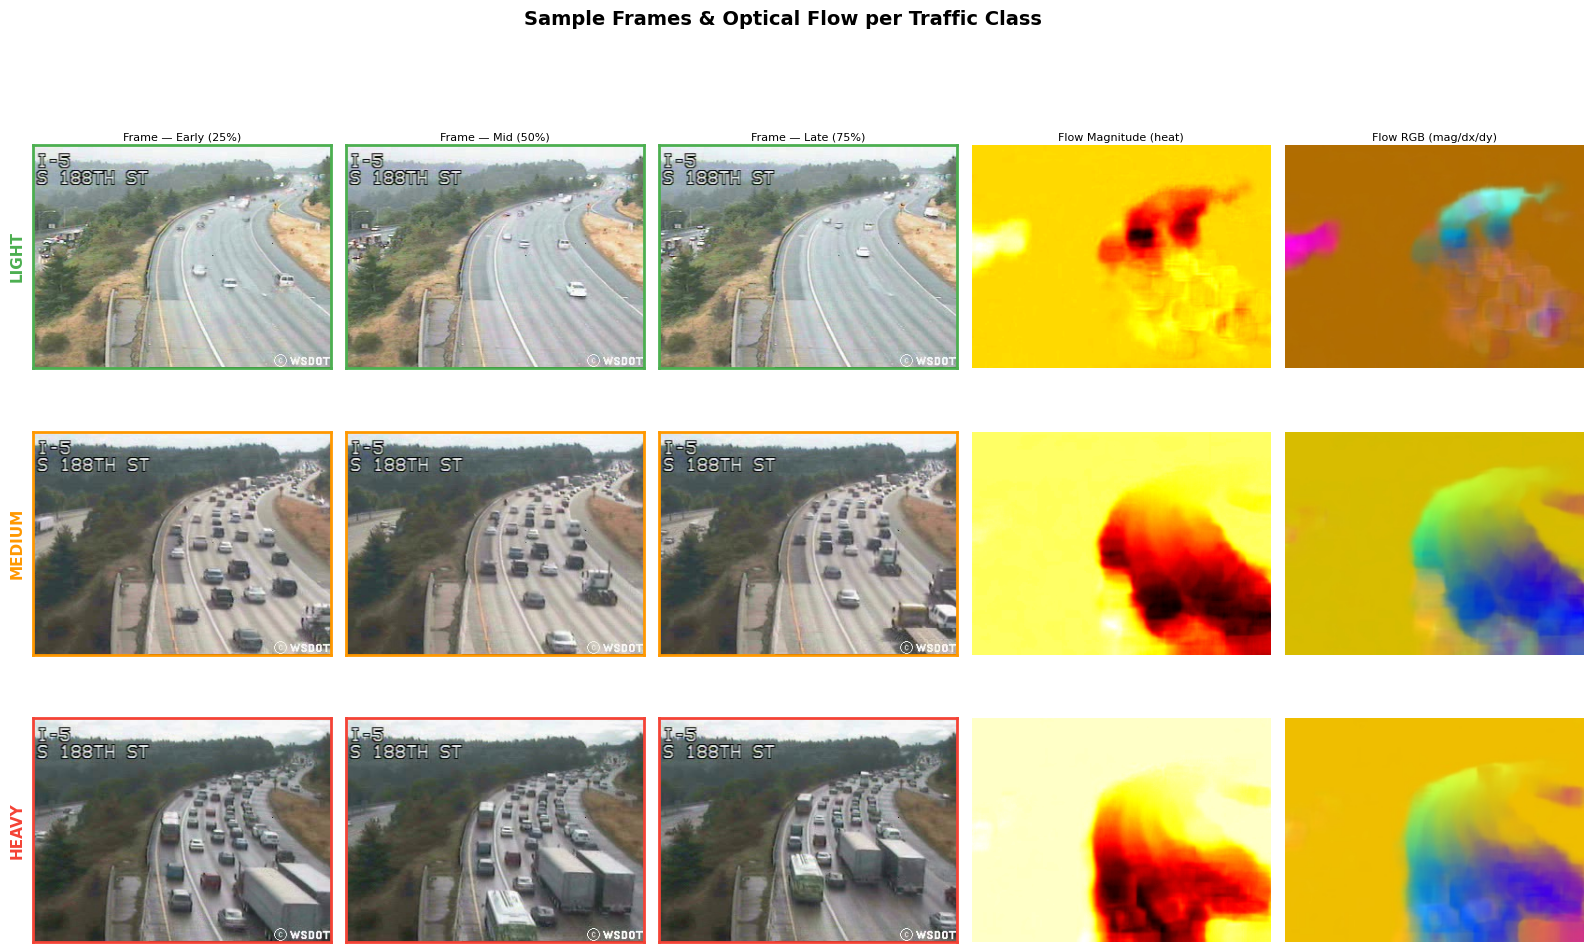

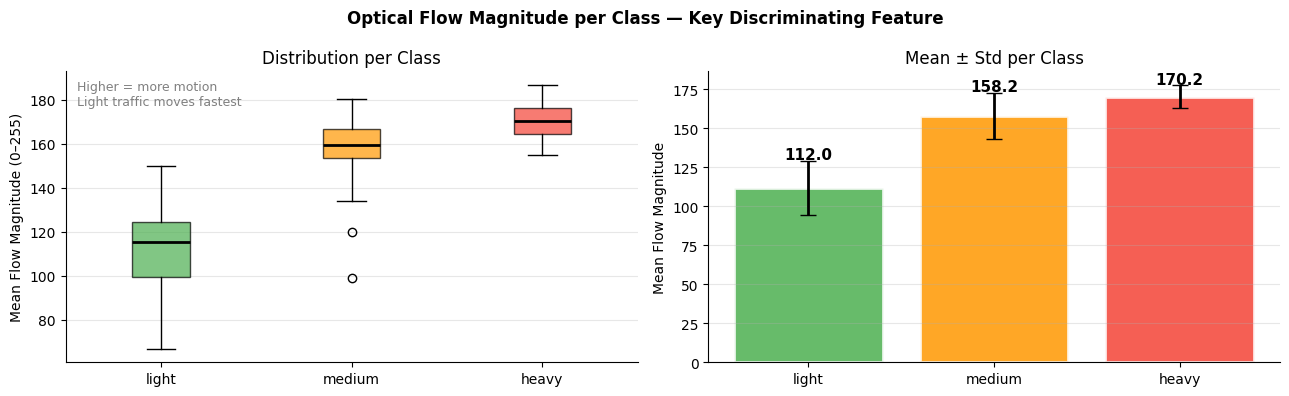

In [6]:
# ── 5A: Sample frames + flow grid ─────────────────────────────────────────────
fig = plt.figure(figsize=(20, 11))
fig.suptitle('Sample Frames & Optical Flow per Traffic Class', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(3, 5, figure=fig, hspace=0.05, wspace=0.05)
col_titles = ['Frame — Early (25%)', 'Frame — Mid (50%)',
              'Frame — Late (75%)', 'Flow Magnitude (heat)', 'Flow RGB (mag/dx/dy)']

for ri, cls in enumerate(CLASS_NAMES):
    sample = meta_df[meta_df['label']==cls].sample(1, random_state=ri).iloc[0]
    flow   = cv2.cvtColor(cv2.imread(sample['flow_path']), cv2.COLOR_BGR2RGB)
    for ci, fp in enumerate(sample['key_frames']):
        ax = fig.add_subplot(gs[ri, ci])
        ax.imshow(cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2RGB))
        if ri == 0: ax.set_title(col_titles[ci], fontsize=8, pad=3)
        if ci == 0:
            ax.set_ylabel(cls.upper(), fontsize=11, fontweight='bold',
                          color=CLASS_COLORS[ri], labelpad=6)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for sp in ax.spines.values(): sp.set_edgecolor(CLASS_COLORS[ri]); sp.set_linewidth(2)
    ax4 = fig.add_subplot(gs[ri, 3])
    ax4.imshow(flow[:,:,0], cmap='hot')
    if ri == 0: ax4.set_title(col_titles[3], fontsize=8, pad=3)
    ax4.axis('off')
    ax5 = fig.add_subplot(gs[ri, 4])
    ax5.imshow(flow)
    if ri == 0: ax5.set_title(col_titles[4], fontsize=8, pad=3)
    ax5.axis('off')

plt.savefig('/content/samples_grid.png', dpi=120, bbox_inches='tight')
plt.show()

# ── 5B: Flow magnitude statistics per class ───────────────────────────────────
flow_stats = {cls: [] for cls in CLASS_NAMES}
for _, row in meta_df.iterrows():
    fl = cv2.imread(row['flow_path'], cv2.IMREAD_GRAYSCALE)
    flow_stats[row['label']].append(float(fl.mean()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Optical Flow Magnitude per Class — Key Discriminating Feature',
             fontsize=12, fontweight='bold')

# Box plot
bplot = axes[0].boxplot([flow_stats[c] for c in CLASS_NAMES],
                         patch_artist=True, labels=CLASS_NAMES,
                         medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bplot['boxes'], CLASS_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_ylabel('Mean Flow Magnitude (0–255)')
axes[0].set_title('Distribution per Class')
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)
axes[0].text(0.02, 0.97, 'Higher = more motion\nLight traffic moves fastest',
             transform=axes[0].transAxes, fontsize=9,
             va='top', color='gray')

# Mean bar chart with std
means = [np.mean(flow_stats[c]) for c in CLASS_NAMES]
stds  = [np.std(flow_stats[c])  for c in CLASS_NAMES]
bars  = axes[1].bar(CLASS_NAMES, means, color=CLASS_COLORS,
                    alpha=0.85, edgecolor='white', linewidth=2)
axes[1].errorbar(CLASS_NAMES, means, yerr=stds, fmt='none',
                  color='black', capsize=6, linewidth=2)
for bar, m, s in zip(bars, means, stds):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + s + 1,
                 f'{m:.1f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Mean Flow Magnitude')
axes[1].set_title('Mean ± Std per Class')
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/flow_statistics.png', dpi=120, bbox_inches='tight')
plt.show()

## 🔄 Step 6 — Dataset & DataLoaders

In [7]:
MEAN = [0.485, 0.456, 0.406]; STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE+32, IMG_SIZE+32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15, hue=0.04),
    transforms.RandomGrayscale(0.08),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class TrafficDS(Dataset):
    def __init__(self, df, tf, train=True):
        self.df = df.reset_index(drop=True)
        self.tf = tf; self.train = train
    def __len__(self): return len(self.df)
    def _read(self, p): return cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    def _pair(self, fp, flp):
        fr = self._read(fp); fl = self._read(flp)
        s = random.randint(0, 9999)
        random.seed(s); torch.manual_seed(s); ft = self.tf(fr)
        random.seed(s); torch.manual_seed(s); flt = self.tf(fl)
        return torch.cat([ft, flt], 0)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        fp = random.choice(r['key_frames']) if self.train else r['key_frames'][1]
        return self._pair(fp, r['flow_path']), CLASS_TO_IDX[r['label']]

def make_loaders(tr, va, te):
    c = tr['label'].value_counts().to_dict()
    w = [1/c[l] for l in tr['label']]
    s = WeightedRandomSampler(w, len(w), replacement=True)
    kw = dict(num_workers=2, pin_memory=True)
    return (DataLoader(TrafficDS(tr, train_tf, True),  BATCH_SIZE, sampler=s, **kw),
            DataLoader(TrafficDS(va, val_tf,   False), BATCH_SIZE, shuffle=False, **kw),
            DataLoader(TrafficDS(te, val_tf,   False), BATCH_SIZE, shuffle=False, **kw))

def mixup(x, y, a=MIXUP_ALPHA):
    if a <= 0: return x, y, y, 1.0
    lam = np.random.beta(a, a)
    p   = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[p], y, y[p], lam

x0, y0 = TrafficDS(meta_df.head(2), val_tf, False)[0]
print(f'Tensor shape : {x0.shape}  (6 channels = 3 RGB + 3 flow)')
print(f'Label        : {CLASS_NAMES[y0]}')

Tensor shape : torch.Size([6, 224, 224])  (6 channels = 3 RGB + 3 flow)
Label        : heavy


## 🧠 Step 7 — Model: EfficientNet-B0 + Stochastic Depth

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

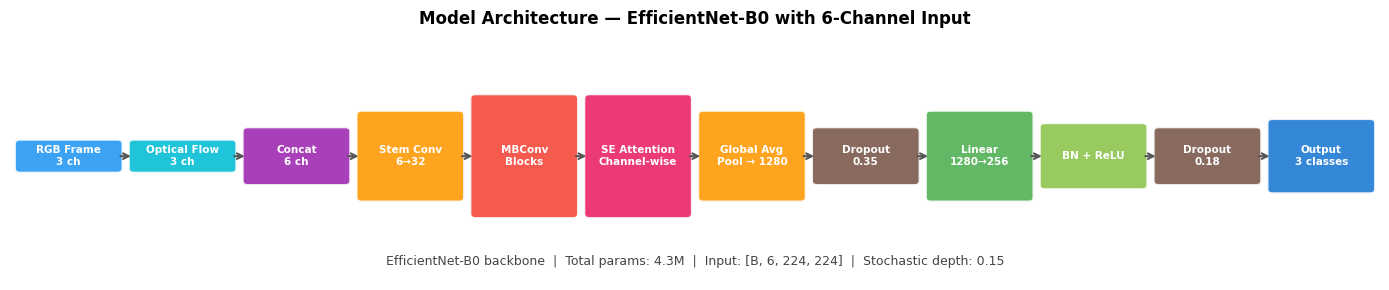

In [8]:
class TrafficModel(nn.Module):
    def __init__(self, nc=3, inch=6, dr=DROPOUT, dp=STOCH_DEPTH):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b0', pretrained=True, num_classes=0,
            global_pool='avg', drop_path_rate=dp)
        orig = self.backbone.conv_stem
        new  = nn.Conv2d(inch, orig.out_channels, orig.kernel_size,
                         orig.stride, orig.padding, bias=False)
        with torch.no_grad():
            new.weight[:,:3] = orig.weight.clone()
            new.weight[:,3:] = orig.weight.clone()
            new.weight      *= 0.5
        self.backbone.conv_stem = new
        f = self.backbone.num_features  # 1280
        self.head = nn.Sequential(
            nn.Dropout(dr),
            nn.Linear(f, 256), nn.BatchNorm1d(256), nn.ReLU(True),
            nn.Dropout(dr*0.5),
            nn.Linear(256, nc)
        )
    def forward(self, x): return self.head(self.backbone(x))

# ── Architecture diagram visualisation ───────────────────────────────────────
m = TrafficModel().to(DEVICE)
total = sum(p.numel() for p in m.parameters())

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')
ax.set_xlim(0, 14); ax.set_ylim(0, 3)

blocks = [
    ('RGB Frame\n3 ch', '#2196F3', 0.3),
    ('Optical Flow\n3 ch', '#00BCD4', 0.3),
    ('Concat\n6 ch', '#9C27B0', 0.6),
    ('Stem Conv\n6→32', '#FF9800', 1.0),
    ('MBConv\nBlocks', '#F44336', 1.4),
    ('SE Attention\nChannel-wise', '#E91E63', 1.4),
    ('Global Avg\nPool → 1280', '#FF9800', 1.0),
    ('Dropout\n0.35', '#795548', 0.6),
    ('Linear\n1280→256', '#4CAF50', 1.0),
    ('BN + ReLU', '#8BC34A', 0.7),
    ('Dropout\n0.18', '#795548', 0.6),
    ('Output\n3 classes', '#1976D2', 0.8),
]
x_pos = np.linspace(0.6, 13.4, len(blocks))
for (label, color, h), x in zip(blocks, x_pos):
    rect = mpatches.FancyBboxPatch((x-0.5, 1.5-h/2), 1.0, h,
                                    boxstyle='round,pad=0.05',
                                    facecolor=color, edgecolor='white',
                                    linewidth=1.5, alpha=0.88)
    ax.add_patch(rect)
    ax.text(x, 1.5, label, ha='center', va='center',
            fontsize=7.5, fontweight='bold', color='white')

for i in range(len(x_pos)-1):
    ax.annotate('', xy=(x_pos[i+1]-0.5, 1.5), xytext=(x_pos[i]+0.5, 1.5),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

ax.text(7, 0.18, f'EfficientNet-B0 backbone  |  Total params: {total/1e6:.1f}M  |  '
        f'Input: [B, 6, 224, 224]  |  Stochastic depth: {STOCH_DEPTH}',
        ha='center', fontsize=9, color='#444')
ax.set_title('Model Architecture — EfficientNet-B0 with 6-Channel Input',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('/content/model_arch.png', dpi=120, bbox_inches='tight')
plt.show()
del m

## 🔥 Step 8 — Focal Loss with Class Weights

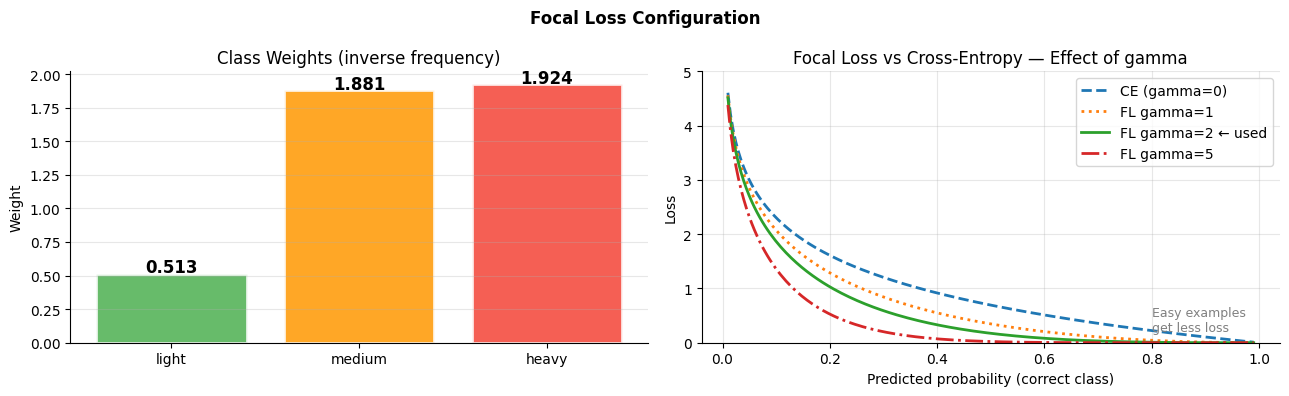

Class weights: [0.513, 1.881, 1.924]
medium/heavy get 3.7x more focus than light


In [9]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, smooth=0.1, nc=3):
        super().__init__()
        self.gamma = gamma; self.smooth = smooth; self.nc = nc
        self.alpha = torch.tensor(alpha, dtype=torch.float32) if alpha else None
    def forward(self, logits, targets):
        with torch.no_grad():
            s = torch.full_like(logits, self.smooth/(self.nc-1))
            s.scatter_(1, targets.unsqueeze(1), 1.0-self.smooth)
        lp  = F.log_softmax(logits, 1)
        pt  = lp.exp().gather(1, targets.unsqueeze(1)).squeeze(1)
        fw  = (1-pt)**self.gamma
        los = -(s*lp).sum(1)
        if self.alpha is not None:
            at = self.alpha.to(logits.device)[targets]
            los = at*fw*los
        else: los = fw*los
        return los.mean()

N = 254
ca = [N/(3*165), N/(3*45), N/(3*44)]

# ── Loss comparison visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Focal Loss Configuration', fontsize=12, fontweight='bold')

bars = axes[0].bar(CLASS_NAMES, ca, color=CLASS_COLORS, alpha=0.85,
                   edgecolor='white', linewidth=2)
for bar, v in zip(bars, ca):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Class Weights (inverse frequency)')
axes[0].set_ylabel('Weight'); axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

p  = np.linspace(0.01, 0.99, 200)
ce = -np.log(p)
for g, ls, lbl in [(0,'--','CE (gamma=0)'), (1,':','FL gamma=1'),
                    (2,'-','FL gamma=2 ← used'), (5,'-.','FL gamma=5')]:
    axes[1].plot(p, ((1-p)**g)*ce, ls=ls, lw=2, label=lbl)
axes[1].set_xlabel('Predicted probability (correct class)')
axes[1].set_ylabel('Loss')
axes[1].set_title('Focal Loss vs Cross-Entropy — Effect of gamma')
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_ylim(0, 5)
axes[1].spines[['top','right']].set_visible(False)
axes[1].annotate('Easy examples\nget less loss',
                  xy=(0.8, 0.22), fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('/content/focal_loss.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Class weights: {[round(w,3) for w in ca]}')
print(f'medium/heavy get {ca[1]/ca[0]:.1f}x more focus than light')

## 🏋️ Step 9 — Training Functions

In [10]:
def train_ep(model, loader, opt, crit, scaler):
    model.train()
    tl = tc = tt = 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        Xm, ya, yb, lam = mixup(X, y)
        opt.zero_grad()
        with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
            lg = model(Xm)
            loss = lam*crit(lg,ya) + (1-lam)*crit(lg,yb)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update()
        tl += loss.item()*X.size(0)
        with torch.no_grad(): tc += (model(X).argmax(1)==y).sum().item()
        tt += X.size(0)
    return tl/tt, tc/tt

@torch.no_grad()
def eval_ep(model, loader, crit):
    model.eval()
    tl = tc = tt = 0
    ps, ls = [], []
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        lg = model(X); loss = crit(lg, y)
        tl += loss.item()*X.size(0)
        pr  = lg.argmax(1)
        tc += (pr==y).sum().item(); tt += X.size(0)
        ps.extend(pr.cpu().numpy()); ls.extend(y.cpu().numpy())
    return tl/tt, tc/tt, ps, ls

print('✅ Training functions defined')

✅ Training functions defined


## 🔁 Step 10 — 4-Fold Cross Validation

In [11]:
fold_results = []; trained_models = []

for fold_id in range(len(train_folds)):
    print(f'\n{"═"*55}\n  FOLD {fold_id+1} / {len(train_folds)}\n{"═"*55}')

    tr_rows = meta_df[meta_df['video_idx'].isin(train_folds[fold_id])].copy()
    te_rows = meta_df[meta_df['video_idx'].isin(test_folds[fold_id])].copy()
    tr_sub, va_sub = train_test_split(tr_rows, test_size=0.1,
                                      random_state=SEED, stratify=tr_rows['label'])

    print(f'  train={len(tr_sub)} | val={len(va_sub)} | test={len(te_rows)}')
    tr_ld, va_ld, te_ld = make_loaders(tr_sub, va_sub, te_rows)

    model = TrafficModel().to(DEVICE)
    crit  = FocalLoss(gamma=2.0, alpha=ca, smooth=0.1)
    scaler= torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))
    opt   = optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': LR_BACKBONE},
        {'params': model.head.parameters(),     'lr': LR_HEAD}
    ], weight_decay=WEIGHT_DECAY)
    sched = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=8, T_mult=1, eta_min=1e-6)

    hist = {'tr_acc':[],'va_acc':[],'tr_loss':[],'va_loss':[],'gap':[]}
    best_acc = 0.0; best_st = None; pat = 0
    ckpt = f'/content/drive/MyDrive/ML lab Colab/fold{fold_id}_v4.pth'

    print(f'  Ep   TrAcc  VaAcc  Gap    LR')
    print(f'  {"-"*38}')

    for ep in range(1, EPOCHS+1):
        if ep == 1:              [p.__setattr__('requires_grad', False) for p in model.backbone.parameters()]
        if ep == WARMUP_EPOCHS+1:[p.__setattr__('requires_grad', True)  for p in model.backbone.parameters()]

        trl, tra = train_ep(model, tr_ld, opt, crit, scaler)
        val, vaa, _, _ = eval_ep(model, va_ld, crit)
        if ep > WARMUP_EPOCHS: sched.step()

        gap = tra - vaa
        for k,v in [('tr_acc',tra),('va_acc',vaa),
                    ('tr_loss',trl),('va_loss',val),('gap',gap)]:
            hist[k].append(v)

        saved = ''
        if vaa > best_acc:
            best_acc = vaa
            best_st  = {k:v.cpu().clone() for k,v in model.state_dict().items()}
            torch.save({'model_state':best_st,'val_acc':vaa,
                        'fold':fold_id,'epoch':ep}, ckpt)
            pat = 0; saved = 'saved'
        else:
            pat += 1
            if pat >= PATIENCE: print(f'  Early stop ep {ep}'); break

        lr_now = opt.param_groups[1]['lr']
        flag   = ' ⚠' if abs(gap) > 0.08 else ''
        print(f'  {ep:2d}   {tra:.1%}  {vaa:.1%}  {gap:+.1%}  {lr_now:.2e}  {saved}{flag}')

    model.load_state_dict(best_st)
    _, te_acc, preds, labels = eval_ep(model, te_ld, crit)
    avg_gap = float(np.mean(hist['gap'][-5:]))

    print(f'\n  Test accuracy (single model, no TTA) : {te_acc:.1%}')
    print(f'  Train-val gap                         : {avg_gap:+.1%}')

    fold_results.append({'fold':fold_id,'val_acc':best_acc,'test_acc':te_acc,
                         'preds':preds,'labels':labels,'history':hist,
                         'avg_gap':avg_gap})
    trained_models.append(model)

accs = [r['test_acc'] for r in fold_results]
gaps = [r['avg_gap']  for r in fold_results]
print(f'\n{"═"*55}')
print('  SUMMARY  (single model — no TTA — no ensemble)')
print(f'{"═"*55}')
for r in fold_results:
    print(f'  Fold {r["fold"]+1}: {r["test_acc"]:.1%}  gap={r["avg_gap"]:+.1%}')
print(f'  ─────────────────────────')
print(f'  Mean : {np.mean(accs):.1%}  Std : {np.std(accs):.1%}')
print(f'  Mean gap : {np.mean(gaps):+.1%}  (healthy if |gap| < 5%)')


═══════════════════════════════════════════════════════
  FOLD 1 / 4
═══════════════════════════════════════════════════════
  train=171 | val=20 | test=63
  Ep   TrAcc  VaAcc  Gap    LR
  --------------------------------------
   1   72.5%  85.0%  -12.5%  8.00e-04  saved ⚠
   2   71.9%  90.0%  -18.1%  8.00e-04  saved ⚠
   3   82.5%  90.0%  -7.5%  8.00e-04  
   4   88.3%  95.0%  -6.7%  7.70e-04  saved
   5   91.8%  95.0%  -3.2%  6.83e-04  
   6   90.1%  95.0%  -4.9%  5.53e-04  
   7   93.6%  90.0%  +3.6%  4.01e-04  
   8   87.7%  95.0%  -7.3%  2.48e-04  
   9   94.7%  95.0%  -0.3%  1.18e-04  
  10   95.3%  95.0%  +0.3%  3.14e-05  
  Early stop ep 11

  Test accuracy (single model, no TTA) : 93.7%
  Train-val gap                         : -0.7%

═══════════════════════════════════════════════════════
  FOLD 2 / 4
═══════════════════════════════════════════════════════
  train=171 | val=19 | test=64
  Ep   TrAcc  VaAcc  Gap    LR
  --------------------------------------
   1   76.6%  89

  Ep   TrAcc  VaAcc  Gap    LR
  --------------------------------------
   1   77.2%  100.0%  -22.8%  8.00e-04  saved ⚠
   2   81.3%  94.7%  -13.5%  8.00e-04   ⚠
   3   78.9%  89.5%  -10.5%  8.00e-04   ⚠
   4   89.5%  89.5%  +0.0%  7.70e-04  
   5   86.5%  89.5%  -2.9%  6.83e-04  
   6   87.7%  89.5%  -1.8%  5.53e-04  
   7   93.0%  94.7%  -1.8%  4.01e-04  
  Early stop ep 8

  Test accuracy (single model, no TTA) : 92.2%
  Train-val gap                         : -1.2%

═══════════════════════════════════════════════════════
  FOLD 4 / 4
═══════════════════════════════════════════════════════
  train=171 | val=20 | test=63
  Ep   TrAcc  VaAcc  Gap    LR
  --------------------------------------
   1   83.6%  90.0%  -6.4%  8.00e-04  saved
   2   84.8%  90.0%  -5.2%  8.00e-04  
   3   87.1%  95.0%  -7.9%  8.00e-04  saved
   4   89.5%  90.0%  -0.5%  7.70e-04  
   5   94.7%  95.0%  -0.3%  6.83e-04  
   6   91.2%  95.0%  -3.8%  5.53e-04  
   7   92.4%  95.0%  -2.6%  4.01e-04  
   8   88.9%  

## 📈 Step 11 — Training Curves

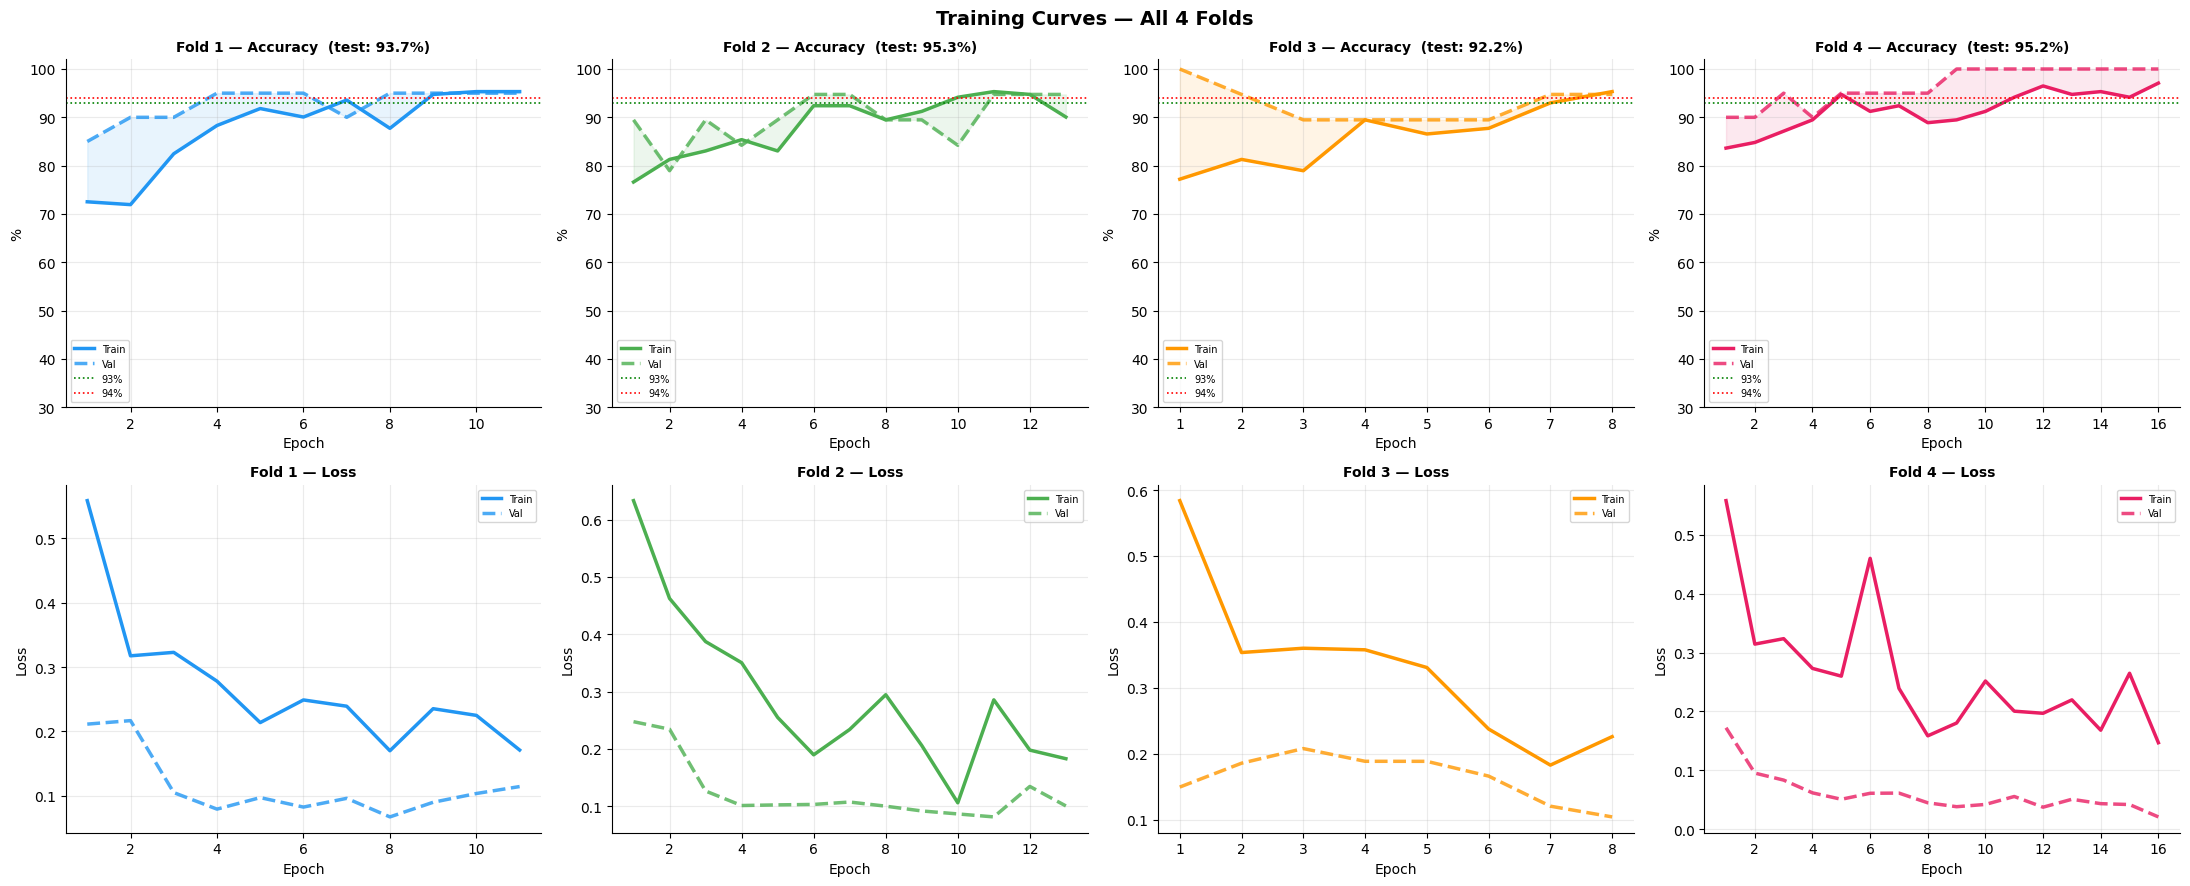

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle('Training Curves — All 4 Folds', fontsize=14, fontweight='bold')
fold_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for r in fold_results:
    h   = r['history']; fi = r['fold']; col = fold_colors[fi]
    ep  = range(1, len(h['tr_acc']) + 1)
    tra = [x * 100 for x in h['tr_acc']]
    vaa = [x * 100 for x in h['va_acc']]

    # accuracy curve
    ax = axes[0, fi]
    ax.plot(ep, tra, color=col, lw=2.5, label='Train')
    ax.plot(ep, vaa, color=col, lw=2.5, ls='--', label='Val', alpha=0.8)
    ax.fill_between(ep, tra, vaa, alpha=0.10, color=col)
    ax.axhline(93, color='green', ls=':', lw=1.2, label='93%')
    ax.axhline(94, color='red',   ls=':', lw=1.2, label='94%')
    ax.set_title(f'Fold {fi+1} — Accuracy  (test: {r["test_acc"]:.1%})',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('%'); ax.set_xlabel('Epoch')
    ax.set_ylim(30, 102); ax.legend(fontsize=7); ax.grid(alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

    # loss curve
    ax2 = axes[1, fi]
    ax2.plot(ep, h['tr_loss'], color=col, lw=2.5, label='Train')
    ax2.plot(ep, h['va_loss'], color=col, lw=2.5, ls='--', label='Val', alpha=0.8)
    ax2.set_title(f'Fold {fi+1} — Loss', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Loss'); ax2.set_xlabel('Epoch')
    ax2.legend(fontsize=7); ax2.grid(alpha=0.25)
    ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()


## 🎯 Step 12 — Confusion Matrices

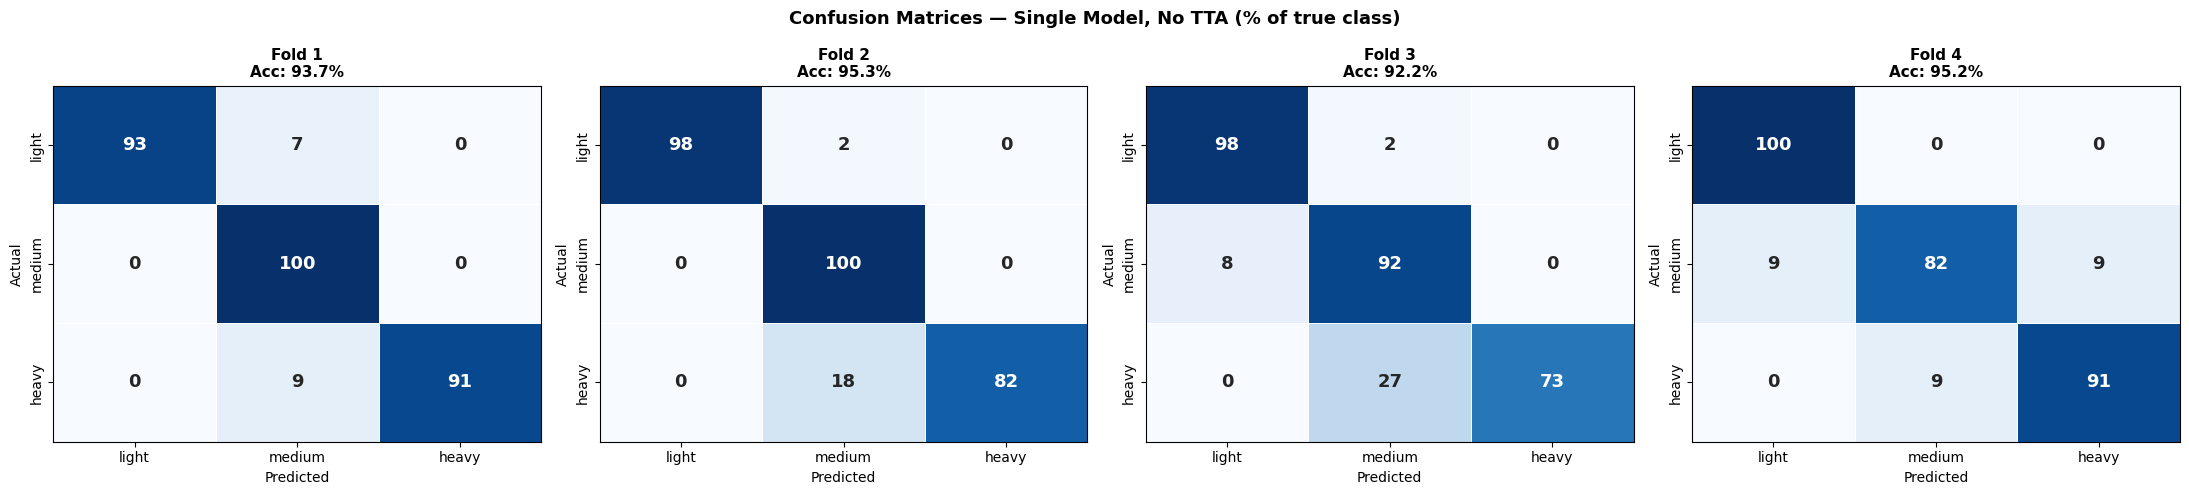

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Confusion Matrices — Single Model, No TTA (% of true class)',
             fontsize=13, fontweight='bold')

for r in fold_results:
    cm  = confusion_matrix(r['labels'], r['preds'])
    pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    ax  = axes[r['fold']]
    sns.heatmap(pct, annot=True, fmt='.0f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, vmin=0, vmax=100, cbar=False,
                linewidths=0.5, linecolor='white',
                annot_kws={'size':13, 'weight':'bold'})
    ax.set_title(f'Fold {r["fold"]+1}\nAcc: {r["test_acc"]:.1%}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    for spine in ax.spines.values(): spine.set_visible(True)

plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## 📋 Step 13 — Per-Class Performance Report

In [14]:
all_preds  = [p for r in fold_results for p in r['preds']]
all_labels = [l for r in fold_results for l in r['labels']]

print('Per-class report — aggregated across all 4 folds:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))


Per-class report — aggregated across all 4 folds:
              precision    recall  f1-score   support

       light       0.99      0.97      0.98       165
      medium       0.78      0.93      0.85        45
       heavy       0.97      0.84      0.90        44

    accuracy                           0.94       254
   macro avg       0.91      0.91      0.91       254
weighted avg       0.95      0.94      0.94       254



## 🏆 Step 14 — Final Results

Test accuracy per fold :
  Fold 1: 93.7%  █████████████████████████████████████
  Fold 2: 95.3%  ██████████████████████████████████████
  Fold 3: 92.2%  ████████████████████████████████████
  Fold 4: 95.2%  ██████████████████████████████████████

Mean : 94.1% ± 1.3%
Gap  : 2.0%


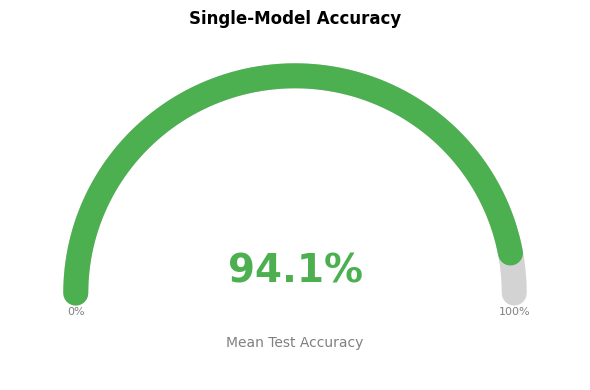

In [19]:
mean_acc = np.mean(accs)
std_acc  = np.std(accs)
mean_gap = np.mean(np.abs(gaps))
acc_ok   = mean_acc >= 0.93
gap_ok   = mean_gap < 0.05

# test accuracy per fold
print('Test accuracy per fold :')
for r in fold_results:
    bar = '█' * int(r['test_acc'] * 40)
    print(f'  Fold {r["fold"]+1}: {r["test_acc"]:.1%}  {bar}')

# summary numbers
print()
print(f'Mean : {mean_acc:.1%} ± {std_acc:.1%}')
print(f'Gap  : {mean_gap:.1%}')

# Mean accuracy gauge
fig, ax4 = plt.subplots(figsize=(6, 4))

theta = np.linspace(0, np.pi, 300)
ax4.plot(np.cos(theta), np.sin(theta), 'lightgray', lw=18, solid_capstyle='round')

fill_to    = np.pi * (1 - mean_acc)
theta_fill = np.linspace(fill_to, np.pi, 200)
c = '#4CAF50' if acc_ok else '#FF9800'
ax4.plot(np.cos(theta_fill), np.sin(theta_fill), c, lw=18, solid_capstyle='round')

ax4.text(0,  0.1,  f'{mean_acc:.1%}',     ha='center', va='center', fontsize=28, fontweight='bold', color=c)
ax4.text(0, -0.25, 'Mean Test Accuracy',   ha='center', fontsize=10, color='gray')
ax4.text(-1, -0.1, '0%',                  ha='center', fontsize=8,  color='gray')
ax4.text(1,  -0.1, '100%',                ha='center', fontsize=8,  color='gray')

ax4.set_xlim(-1.3, 1.3)
ax4.set_ylim(-0.4, 1.2)
ax4.axis('off')
ax4.set_title('Single-Model Accuracy', fontweight='bold')

plt.tight_layout()
plt.show()



## 💾 Step 15 — Save Model to Drive

In [21]:
best_fold_id = int(np.argmax(accs))
best_model   = trained_models[best_fold_id]

save_path = '/content/drive/MyDrive/ML lab Colab/highway_traffic.pth'
torch.save({
    'model_state'  : best_model.state_dict(),
    'all_states'   : [m.state_dict() for m in trained_models],
    'class_names'  : CLASS_NAMES,
    'class_to_idx' : CLASS_TO_IDX,
    'fold_accs'    : accs,
    'mean_acc'     : float(mean_acc),
    'mean_gap'     : float(mean_gap),
    'best_fold'    : best_fold_id,
    'model_arch'   : 'efficientnet_b0',
    'in_channels'  : 6,
    'img_size'     : IMG_SIZE,
    'note'         : 'Single model accuracy — no TTA, no ensemble'
}, save_path)

print(f'Model saved → {save_path}')
print(f'Best fold   : Fold {best_fold_id+1} ({max(accs):.1%})')
print(f'Mean acc    : {mean_acc:.1%}')

Model saved → /content/drive/MyDrive/ML lab Colab/highway_traffic.pth
Best fold   : Fold 2 (95.3%)
Mean acc    : 94.1%


## 🔮 Step 16 — Inference on a New Video

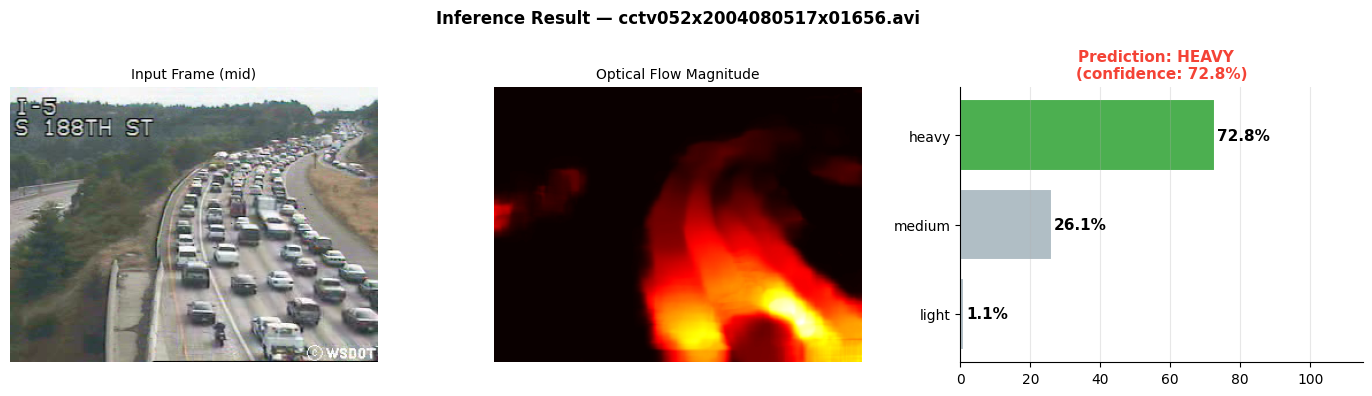

('heavy', array([0.01124546, 0.26054862, 0.7282059 ], dtype=float32))

In [22]:
def predict_single(video_path, model):
    """
    Single forward pass — exactly what the model does in deployment.
    No TTA, no ensemble — honest single-model prediction.
    """
    frames = extract_frames(video_path)
    if not frames: print('Could not read video'); return

    n   = len(frames)
    mid = frames[n//2]
    fr  = cv2.cvtColor(mid, cv2.COLOR_BGR2RGB)
    fl  = compute_flow(frames)

    ft = val_tf(fr); flt = val_tf(fl)
    x  = torch.cat([ft, flt], 0).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(x), 1).squeeze().cpu().numpy()

    pred = CLASS_NAMES[probs.argmax()]

    # ── Visualise result ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f'Inference Result — {Path(video_path).name}',
                 fontsize=12, fontweight='bold')

    axes[0].imshow(fr)
    axes[0].set_title('Input Frame (mid)', fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(fl[:,:,0], cmap='hot')
    axes[1].set_title('Optical Flow Magnitude', fontsize=10)
    axes[1].axis('off')

    colors = ['#4CAF50' if CLASS_NAMES[i]==pred else '#B0BEC5'
              for i in range(3)]
    bars = axes[2].barh(CLASS_NAMES, probs*100, color=colors,
                         edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, probs*100):
        axes[2].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                     f'{v:.1f}%', va='center', fontsize=11, fontweight='bold')
    axes[2].set_xlim(0, 115)
    axes[2].set_title(f'Prediction: {pred.upper()}  \n(confidence: {probs.max():.1%})',
                       fontsize=11, fontweight='bold',
                       color=CLASS_COLORS[CLASS_TO_IDX[pred]])
    axes[2].grid(axis='x', alpha=0.3)
    axes[2].spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.show()
    return pred, probs


# Run on first video
sample = list(VIDEO_DIR.glob('*.avi'))[0]
predict_single(sample, trained_models[best_fold_id])